<a href="https://colab.research.google.com/github/shraddha131004/IPL-match-data-analysis/blob/main/IPL_Analysis_Shraddha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏏 IPL Match Data Analysis (2008–2017)
**By Shraddha Bhendarkar**  
B.Tech IT | SGGS Institute of Engineering & Technology, Nanded

---

### Objective
Perform Exploratory Data Analysis on 10 years of IPL match data (636 matches) to uncover team performance trends, toss impact, top performers, and season-wise patterns using Python.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Section 1: Import Libraries

In [ ]:
# Importing all required libraries
import pandas as pd          # for data manipulation
import numpy as np           # for numerical operations
import matplotlib.pyplot as plt  # for plotting charts
import seaborn as sns        # for better-looking charts
import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## Section 2: Load & Explore the Dataset

In [ ]:
# Load the dataset
# Make sure matches.csv is uploaded to Colab first (use the folder icon on the left sidebar)
df = pd.read_csv('/content/drive/MyDrive/matches.csv')

# Basic exploration
print('Shape of dataset:', df.shape)  # rows x columns
print('\nColumn names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape of dataset: (636, 18)

Column names:
['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']

First 5 rows:


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,5/4/2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,6/4/2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,7/4/2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,8/4/2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,8/4/2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [ ]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               636 non-null    int64  
 1   season           636 non-null    int64  
 2   city             629 non-null    object 
 3   date             636 non-null    object 
 4   team1            636 non-null    object 
 5   team2            636 non-null    object 
 6   toss_winner      636 non-null    object 
 7   toss_decision    636 non-null    object 
 8   result           636 non-null    object 
 9   dl_applied       636 non-null    int64  
 10  winner           633 non-null    object 
 11  win_by_runs      636 non-null    int64  
 12  win_by_wickets   636 non-null    int64  
 13  player_of_match  633 non-null    object 
 14  venue            636 non-null    object 
 15  umpire1          635 non-null    object 
 16  umpire2          635 non-null    object 
 17  umpire3         

In [ ]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Quick note: umpire3 has 636 nulls (all missing) - we'll drop that column
# winner has 3 nulls - these are no-result matches (rain/abandoned)

Missing values per column:
id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64


In [ ]:
# Seasons covered in this dataset
print('Seasons:', sorted(df['season'].unique()))
print('Total matches per season:')
print(df.groupby('season')['id'].count())

Seasons: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]
Total matches per season:
season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
Name: id, dtype: int64


---
## Section 3: Data Cleaning

In [ ]:
# Step 1: Drop umpire3 column - it's completely empty (no useful data)
df.drop(columns=['umpire3'], inplace=True)

# Step 2: Fill missing city with 'Unknown'
df['city'].fillna('Unknown', inplace=True)

# Step 3: Drop rows where winner is missing (no-result matches)
# Only 3 rows - safe to drop
df.dropna(subset=['winner'], inplace=True)

# Confirm cleaning
print('After cleaning:')
print('Remaining rows:', len(df))
print('Any nulls left?', df.isnull().sum().sum())

After cleaning:
Remaining rows: 633
Any nulls left? 2


---
## Section 4: Analysis 1 — Which Team Wins the Most?

**Business question:** Who are the most successful teams in IPL history (2008–2017)?

In [ ]:
# Count wins per team
team_wins = df['winner'].value_counts().reset_index()
team_wins.columns = ['Team', 'Wins']
print(team_wins)

                           Team  Wins
0                Mumbai Indians    92
1           Chennai Super Kings    79
2         Kolkata Knight Riders    77
3   Royal Challengers Bangalore    73
4               Kings XI Punjab    70
5              Rajasthan Royals    63
6              Delhi Daredevils    62
7           Sunrisers Hyderabad    42
8               Deccan Chargers    29
9                 Gujarat Lions    13
10                Pune Warriors    12
11       Rising Pune Supergiant    10
12         Kochi Tuskers Kerala     6
13      Rising Pune Supergiants     5


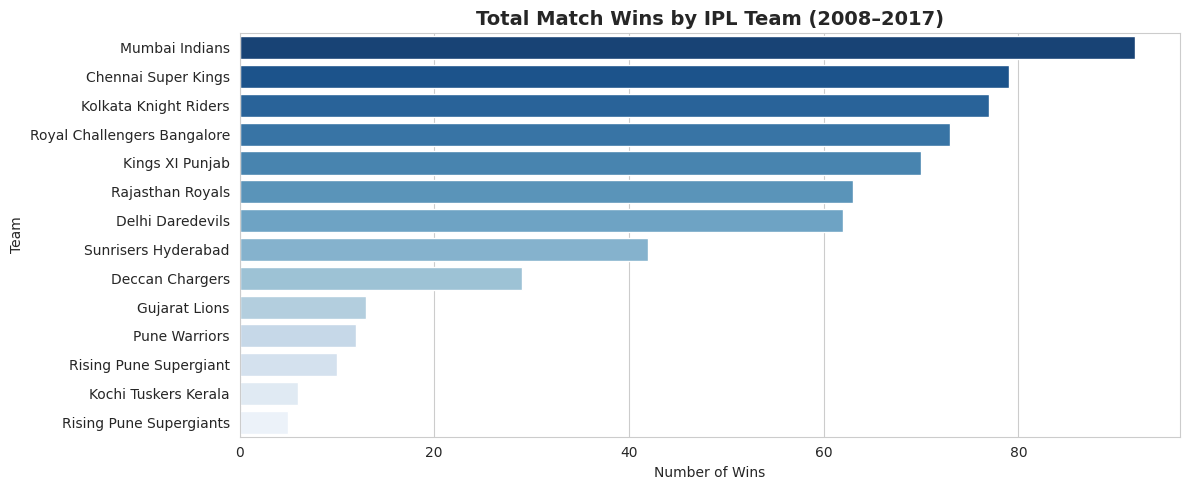


Insight: Mumbai Indians and Chennai Super Kings are the most dominant teams.


In [ ]:
# Chart 1: Bar chart of wins per team
plt.figure(figsize=(12, 5))
sns.barplot(data=team_wins, x='Wins', y='Team', palette='Blues_r')
plt.title('Total Match Wins by IPL Team (2008–2017)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

print('\nInsight: Mumbai Indians and Chennai Super Kings are the most dominant teams.')

---
## Section 5: Analysis 2 — Does Winning the Toss Help?

**Business question:** Is there an advantage to winning the toss in IPL?

In [ ]:
# Check how often the toss winner also won the match
df['toss_match_win'] = df['toss_winner'] == df['winner']

toss_win_count = df['toss_match_win'].value_counts()
print('Toss winner also won the match:')
print(toss_win_count)

win_pct = df['toss_match_win'].mean() * 100
print(f'\nToss winner win rate: {win_pct:.1f}%')

Toss winner also won the match:
toss_match_win
True     325
False    308
Name: count, dtype: int64

Toss winner win rate: 51.3%


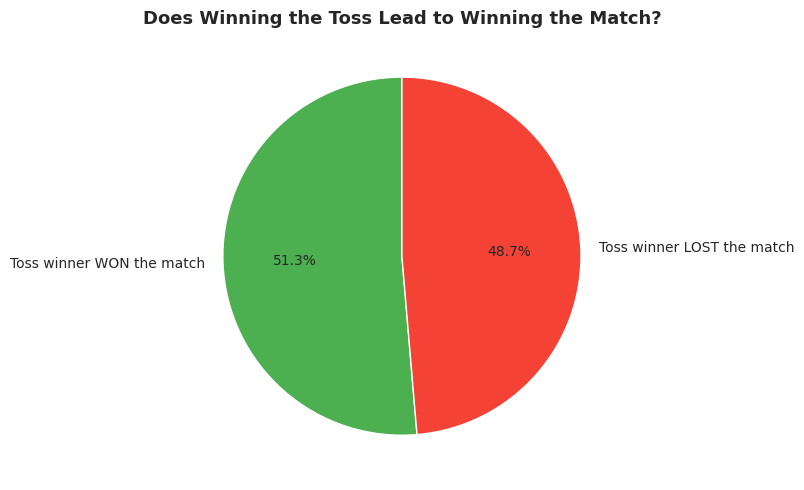

Insight: Toss winners win ~50% of matches — toss alone does not guarantee victory.


In [ ]:
# Chart 2: Pie chart - toss winner vs match winner
labels = ['Toss winner WON the match', 'Toss winner LOST the match']
sizes = [toss_win_count[True], toss_win_count[False]]
colors = ['#4CAF50', '#F44336']

plt.figure(figsize=(7, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Does Winning the Toss Lead to Winning the Match?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: Toss winners win ~50% of matches — toss alone does not guarantee victory.')

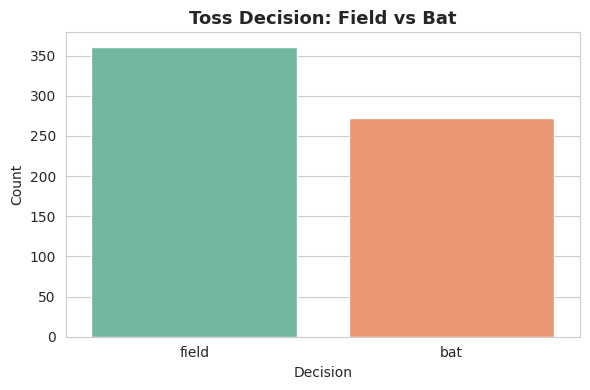

Insight: Most teams prefer to field first after winning the toss — chasing is favored in T20.


In [ ]:
# Chart 3: What decision do teams make after winning the toss?
toss_decision = df['toss_decision'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=toss_decision.index, y=toss_decision.values, palette='Set2')
plt.title('Toss Decision: Field vs Bat', fontsize=13, fontweight='bold')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Insight: Most teams prefer to field first after winning the toss — chasing is favored in T20.')

---
## Section 6: Analysis 3 — Top Players of the Match

**Business question:** Who are the most impactful individual performers in IPL history?

In [ ]:
# Top 10 Player of the Match award winners
top_players = df['player_of_match'].value_counts().head(10).reset_index()
top_players.columns = ['Player', 'Awards']
print(top_players)

           Player  Awards
0        CH Gayle      18
1       YK Pathan      16
2       DA Warner      15
3  AB de Villiers      15
4       RG Sharma      14
5        SK Raina      14
6        MS Dhoni      13
7       G Gambhir      13
8      MEK Hussey      12
9       AM Rahane      12


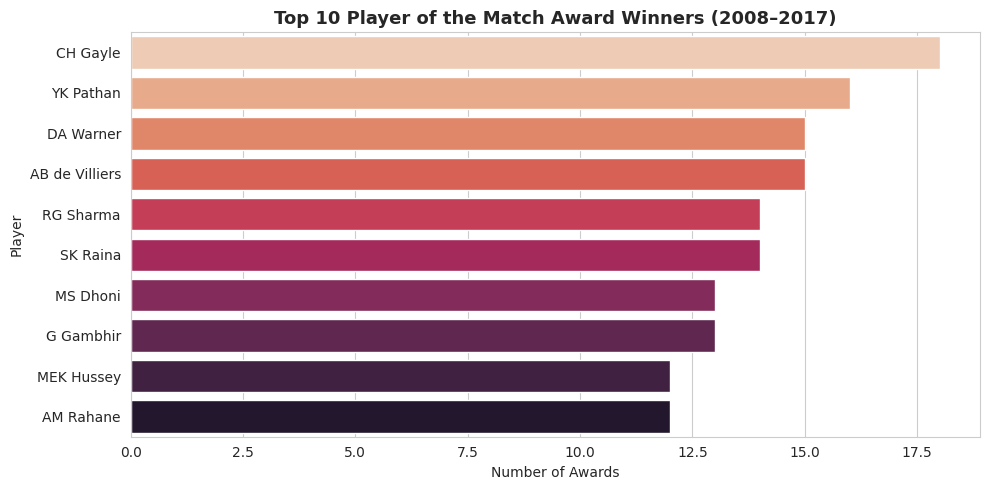

Insight: CH Gayle leads with the most Player of the Match awards — a consistent match-winner.


In [ ]:
# Chart 4: Top 10 Player of the Match
plt.figure(figsize=(10, 5))
sns.barplot(data=top_players, x='Awards', y='Player', palette='rocket_r')
plt.title('Top 10 Player of the Match Award Winners (2008–2017)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

print('Insight: CH Gayle leads with the most Player of the Match awards — a consistent match-winner.')

---
## Section 7: Analysis 4 — Season-wise Match Trends

**Business question:** How has IPL grown in terms of matches played per season?

In [ ]:
# Matches per season
season_matches = df.groupby('season')['id'].count().reset_index()
season_matches.columns = ['Season', 'Matches']
print(season_matches)

   Season  Matches
0    2008       58
1    2009       57
2    2010       60
3    2011       72
4    2012       74
5    2013       76
6    2014       60
7    2015       57
8    2016       60
9    2017       59


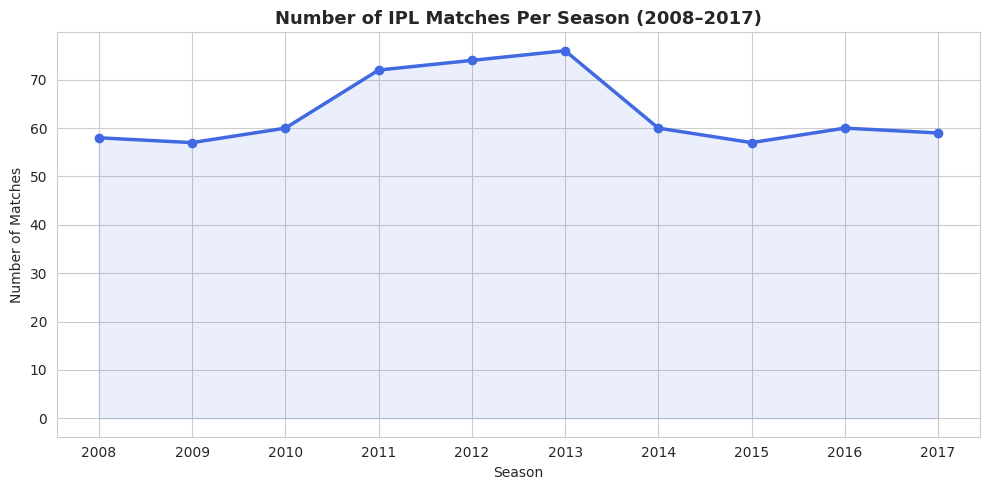

Insight: IPL expanded significantly from 2011 onward with more teams and matches per season.


In [ ]:
# Chart 5: Line chart of matches per season
plt.figure(figsize=(10, 5))
plt.plot(season_matches['Season'], season_matches['Matches'], marker='o', linewidth=2.5, color='royalblue')
plt.fill_between(season_matches['Season'], season_matches['Matches'], alpha=0.1, color='royalblue')
plt.title('Number of IPL Matches Per Season (2008–2017)', fontsize=13, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(season_matches['Season'])
plt.tight_layout()
plt.show()

print('Insight: IPL expanded significantly from 2011 onward with more teams and matches per season.')

---
## Section 8: Analysis 5 — Win by Runs vs Win by Wickets

**Business question:** When batting first, how big are the winning margins? And when chasing?

In [ ]:
# Separate wins by runs (batting first won) vs wins by wickets (chasing team won)
win_by_runs = df[df['win_by_runs'] > 0]['win_by_runs']
win_by_wickets = df[df['win_by_wickets'] > 0]['win_by_wickets']

print(f'Matches won by runs (batting first): {len(win_by_runs)}')
print(f'Average margin: {win_by_runs.mean():.1f} runs')
print(f'\nMatches won by wickets (chasing): {len(win_by_wickets)}')
print(f'Average margin: {win_by_wickets.mean():.1f} wickets')

Matches won by runs (batting first): 287
Average margin: 30.3 runs

Matches won by wickets (chasing): 339
Average margin: 6.3 wickets


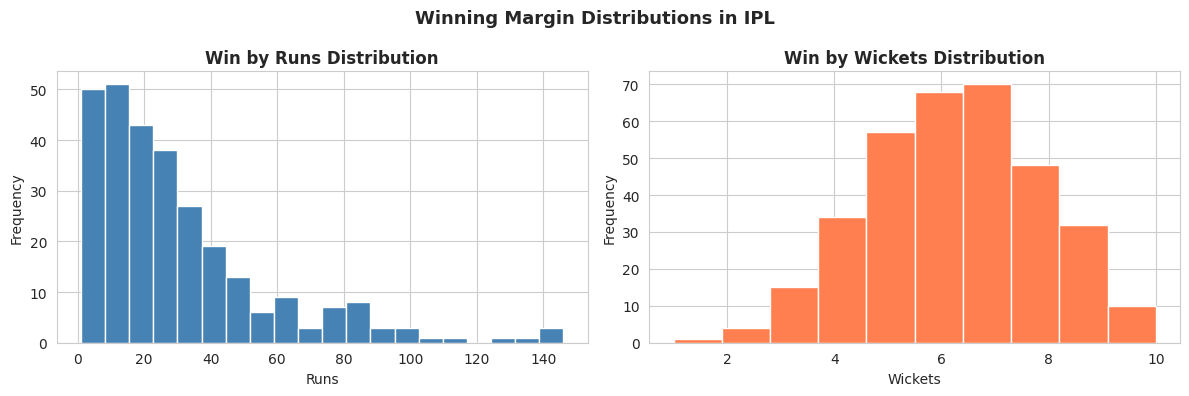

Insight: Most chasing wins happen by 4–7 wickets — close finishes are common in T20.


In [ ]:
# Chart 6: Distribution of win margins by runs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(win_by_runs, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Win by Runs Distribution', fontweight='bold')
axes[0].set_xlabel('Runs')
axes[0].set_ylabel('Frequency')

axes[1].hist(win_by_wickets, bins=10, color='coral', edgecolor='white')
axes[1].set_title('Win by Wickets Distribution', fontweight='bold')
axes[1].set_xlabel('Wickets')
axes[1].set_ylabel('Frequency')

plt.suptitle('Winning Margin Distributions in IPL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: Most chasing wins happen by 4–7 wickets — close finishes are common in T20.')

---
## Section 9: Analysis 6 — Top Venues

**Business question:** Which venues host the most IPL matches?

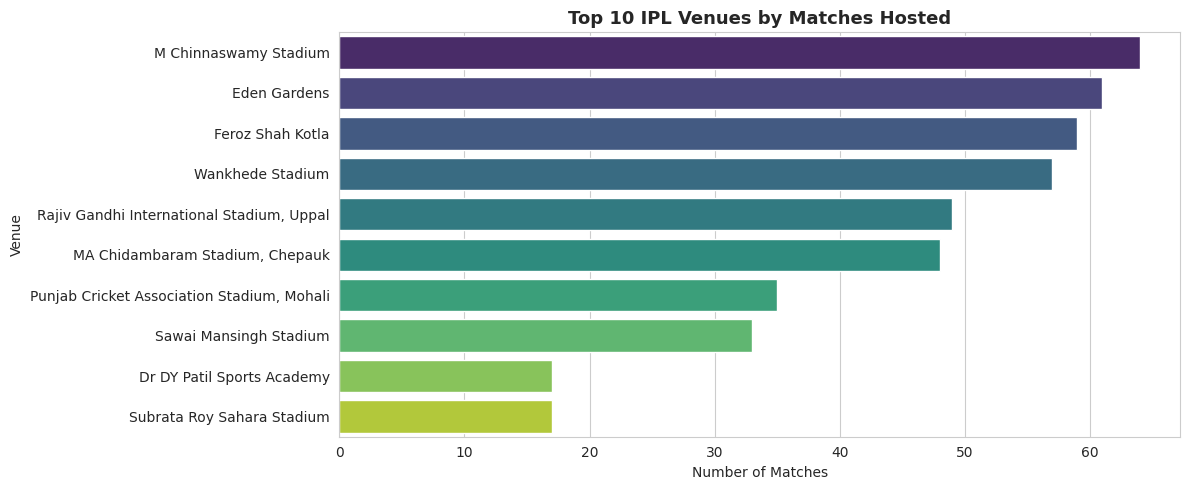

Insight: Eden Gardens (Kolkata) and Wankhede Stadium (Mumbai) are the most frequently used venues.


In [ ]:
# Chart 7: Top 10 venues
top_venues = df['venue'].value_counts().head(10).reset_index()
top_venues.columns = ['Venue', 'Matches']

plt.figure(figsize=(12, 5))
sns.barplot(data=top_venues, x='Matches', y='Venue', palette='viridis')
plt.title('Top 10 IPL Venues by Matches Hosted', fontsize=13, fontweight='bold')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

print('Insight: Eden Gardens (Kolkata) and Wankhede Stadium (Mumbai) are the most frequently used venues.')

---
## Section 10: Analysis 7 — Team Win Rate (Matches Played vs Won)

**Business question:** Which team has the best win percentage — not just raw wins?

In [ ]:
# Count matches played by each team (appeared as team1 or team2)
team1 = df['team1'].value_counts()
team2 = df['team2'].value_counts()
matches_played = (team1.add(team2, fill_value=0)).astype(int)

# Count wins
matches_won = df['winner'].value_counts()

# Combine into a summary dataframe
win_rate_df = pd.DataFrame({'Played': matches_played, 'Won': matches_won}).dropna()
win_rate_df['Win Rate (%)'] = (win_rate_df['Won'] / win_rate_df['Played'] * 100).round(1)
win_rate_df = win_rate_df.sort_values('Win Rate (%)', ascending=False)
print(win_rate_df)

                             Played  Won  Win Rate (%)
Rising Pune Supergiant           16   10          62.5
Chennai Super Kings             131   79          60.3
Mumbai Indians                  157   92          58.6
Sunrisers Hyderabad              76   42          55.3
Rajasthan Royals                117   63          53.8
Kolkata Knight Riders           148   77          52.0
Royal Challengers Bangalore     150   73          48.7
Kings XI Punjab                 148   70          47.3
Gujarat Lions                    30   13          43.3
Kochi Tuskers Kerala             14    6          42.9
Delhi Daredevils                145   62          42.8
Deccan Chargers                  75   29          38.7
Rising Pune Supergiants          14    5          35.7
Pune Warriors                    45   12          26.7


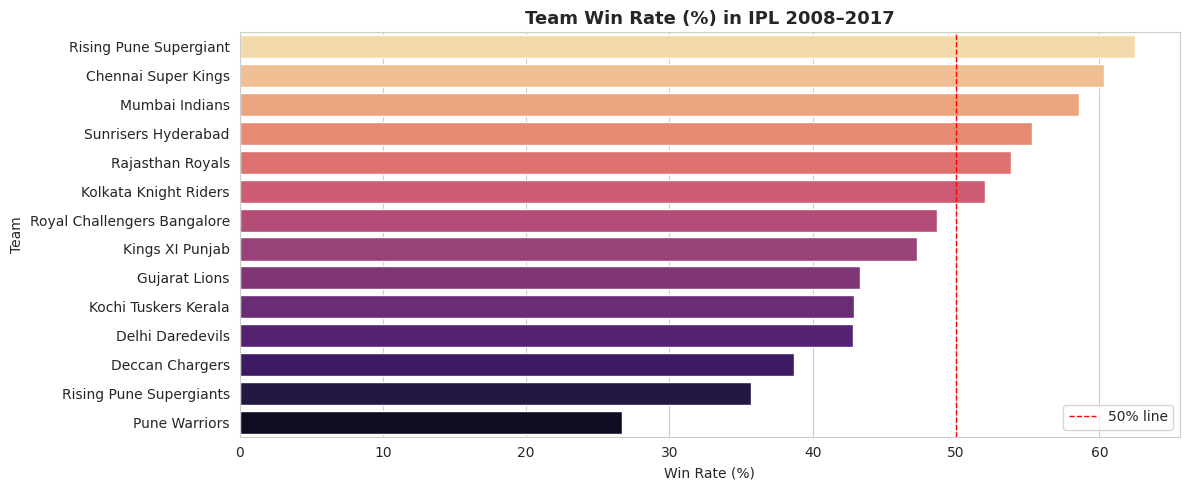

Insight: Chennai Super Kings and Mumbai Indians consistently win more than 50% of their matches.


In [ ]:
# Chart 8: Win rate comparison
plt.figure(figsize=(12, 5))
sns.barplot(data=win_rate_df.reset_index(), x='Win Rate (%)', y='index', palette='magma_r')
plt.title('Team Win Rate (%) in IPL 2008–2017', fontsize=13, fontweight='bold')
plt.xlabel('Win Rate (%)')
plt.ylabel('Team')
plt.axvline(x=50, color='red', linestyle='--', linewidth=1, label='50% line')
plt.legend()
plt.tight_layout()
plt.show()

print('Insight: Chennai Super Kings and Mumbai Indians consistently win more than 50% of their matches.')

---
## Summary: Key Insights from IPL Data Analysis (2008–2017)

| # | Insight |
|---|---|
| 1 | **Mumbai Indians** lead in total wins across all seasons |
| 2 | Toss winners win only ~50% of matches — **toss advantage is minimal** |
| 3 | Teams overwhelmingly prefer to **field first** after winning the toss |
| 4 | **CH Gayle** is the most impactful individual player (most Player of the Match awards) |
| 5 | IPL saw significant expansion from **2011 onward** with more matches per season |
| 6 | Most chasing victories happen by **4–7 wickets**, suggesting close matches are common |
| 7 | **Eden Gardens** and **Wankhede Stadium** are the most frequently used venues |
| 8 | **CSK and MI** have the highest win rates — consistently dominant franchises |

---
*Project by Shraddha Bhendarkar | B.Tech IT | SGGS Institute of Engineering & Technology, Nanded*